In [ ]:
import os
import pickle
from functools import partial
from time import perf_counter

import numpy as np
import tensorflow as tf
from bayesflow import default_settings as defaults
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.helper_networks import MultiConv1D
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
from tensorflow.keras.layers import Dense, GRU, LSTM, Bidirectional
from tensorflow.keras.models import Sequential

In [ ]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
print(f"Job array ID: {job_array_id}")
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))

In [ ]:
train_network = False
presimulate = False
batch_size = 128
iterations_per_epoch = 1000
# 1000 batches to be generated, 1 epoch until batches are used up
max_epochs = 100

In [ ]:
def prior(batch_size: int) -> np.ndarray:
    # all parameters are positive, only delta can be negative (index 2)
    param_batch = np.zeros((batch_size, 12))
    # alpha
    param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # beta
    param_batch[:, 1] = np.random.uniform(0, 10, batch_size)
    # delta
    param_batch[:, 2] = np.random.uniform(-3, 3, batch_size)
    # mu_inf
    param_batch[:, 3:8] = np.random.normal(0, 1, (batch_size, 5))
    #param_batch[:, 3:8] = np.exp(np.random.normal(0, 1, (batch_size, 5)))
    # mu_susc
    param_batch[:, 8:10] = np.random.normal(0, 1, (batch_size, 2))
    #param_batch[:, 8:10] = np.exp(np.random.normal(0, 1, (batch_size, 2)))
    # mu_protect
    param_batch[:, 10:] = np.random.normal(0, 1, (batch_size, 2))
    #param_batch[:, 10:] = np.exp(np.random.normal(0, 1, (batch_size, 2)))
    return param_batch

prior_mean = np.array([0.05, 5, 0, 
                       0, 0, 0, 0, 0, 0, 0, 0, 0])
prior_std = np.array([1/np.sqrt(12)*(0.1-0), 
                     1/np.sqrt(12)*(10-0), 
                      1/np.sqrt(12)*(3+3), 
                      1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    param_names = ['alpha', 'beta', 'delta',
                   'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                   'mu_susc_C', 'mu_susc_A',
                   'mu_protect_acq', 'mu_protect_transm']
    n_households = 128
    length_time_series = 8

    def simulator(params: np.ndarray):
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')

else:
    from Simulator.simulator import simulator, param_names

    _sim = simulator(prior(1).flatten())
    n_households = _sim.shape[0]
    length_time_series = _sim.shape[1]
    print(f"Number of households: {n_households}, Length of time series: {length_time_series}")
n_params = len(param_names)

In [ ]:
bayesflow_prior = Prior(batch_prior_fun=prior, param_names=param_names)
bayes_simulator = Simulator(simulator_fun=simulator)
generative_model = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator,
                                   skip_test=True,
                                   name="Pedcov Household Sampling")

In [ ]:
bayes_simulator_random = Simulator(simulator_fun=partial(simulator, selection_procedure='random'))
generative_model_rand = GenerativeModel(prior=bayesflow_prior, simulator=bayes_simulator_random,
                                        skip_test=True,
                                        name="Random Household Sampling")

In [ ]:
if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(1):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'presimulations/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [ ]:
def custom_loader(file_path):
    """Uses pickle to load, but each path is folder with multiple files, each one batch"""
    # load all files in folder
    loaded_presimulations = []
    for file in os.listdir(file_path):
        with open(os.path.join(file_path, file), 'rb') as batch_file:
            batch = pickle.load(batch_file)[0]
            assert isinstance(batch, dict)  # only one batch per file
            loaded_presimulations.append(batch)
    # shuffle list, so iterations are random, only batches stay the same
    np.random.shuffle(loaded_presimulations)
    return loaded_presimulations

In [ ]:
np.random.seed(42)
# check if the data exists
if os.path.exists('valid_data.pickle'):
    with open('valid_data.pickle', 'rb') as f:
        valid_data = pickle.load(f)
else:
    print('generating validation data')
    valid_data = generative_model(128)

    # save the data
    with open('valid_data.pickle', 'wb') as f:
        pickle.dump(valid_data, f)

np.random.seed(42)  # same seed as before, so prior samples are the same
# check if the data exists
if os.path.exists('valid_data_rand.pickle'):
    with open('valid_data_rand.pickle', 'rb') as f:
        valid_data_rand = pickle.load(f)
else:
    print('generating validation data random')
    valid_data_rand = generative_model_rand(128)

    # save the data
    with open('valid_data_rand.pickle', 'wb') as f:
        pickle.dump(valid_data_rand, f)

In [ ]:
def configurator(forward_dict: dict) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"]
    idx_keep = np.all(np.isfinite(x), axis=(1, 2, 3))
    out_dict['summary_conditions'] = x[idx_keep].astype(np.float32)
    
    # if simulations contains nan
    if not np.all(idx_keep):
        print(f'Invalid value(s) encountered...removing {idx_keep.size - np.sum(idx_keep)} entry(ies) from batch')
    
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params[idx_keep].astype(np.float32)
    return out_dict

In [ ]:
def renormalize_params(params: np.ndarray) -> np.ndarray:
    params_norm = params.copy()
    params_norm = params_norm * prior_std + prior_mean
    # params might be a batch of samples or single set of parameters
    if params_norm.ndim == 2:
        params_norm[:, 3:] = np.exp(params_norm[:, 3:])
    elif params_norm.ndim == 3:
        params_norm[:, :, 3:] = np.exp(params_norm[:, :, 3:])
    else:
        raise ValueError('Invalid number of dimensions')
    return params_norm

In [ ]:
# define the network
class GroupSummaryNetwork(tf.keras.Model):
    """Network to summarize the data of groups of cells.  Each group is passed through a series of convolutional layers
    followed by an LSTM layer. The output of the LSTM layer is then pooled across the groups and dense layer applied
    to obtain a summary of fixed dimensionality. The network is invariant to the order of the groups.
    """
    def __init__(
            self, 
            summary_dim, 
            num_conv_layers=2, 
            rnn_units=128, 
            use_lstm=True, 
            bidirectional=False,
            conv_settings=None, 
            use_attention=False,
            pool_with_sum=False,
            **kwargs
    ):
        super().__init__(**kwargs)
        
        if conv_settings is None:
            conv_settings = defaults.DEFAULT_SETTING_MULTI_CONV

        self.conv = Sequential([MultiConv1D(conv_settings) for _ in range(num_conv_layers)])
        self.use_attention = use_attention
        self.pool_with_sum = pool_with_sum
        
        if use_lstm:
            self.rnn = Bidirectional(LSTM(rnn_units, return_sequences=use_attention)) if bidirectional else LSTM(rnn_units, return_sequences=use_attention)
        else:
            self.rnn = GRU(LSTM(rnn_units, return_sequences=use_attention)) if bidirectional else LSTM(rnn_units, return_sequences=use_attention)

        if self.use_attention:
            self.attention = tf.keras.layers.Attention()
        self.out_layer = Dense(summary_dim, activation="linear")
        self.summary_dim = summary_dim

    def call(self, x, **kwargs):
        """Performs a forward pass through the network by first passing `x` through the same rnn network for
        each household and then pooling the outputs across households.

        Parameters
        ----------
        x : tf.Tensor
            Input of shape (batch_size, n_groups, n_time_steps, n_features)

        Returns
        -------
        out : tf.Tensor
            Output of shape (batch_size, summary_dim)
        """
        # iterate over groups
        out_list = []  # list to store outputs of LSTM for each group
        for g_i in range(x.shape[1]):
            out = self.conv(x[:, g_i], **kwargs)  # (batch_size, n_time_steps, n_filters) -> default: filters=32
            out = self.rnn(out, **kwargs)  # (batch_size, lstm_units) 
            # if attention is used, return full sequence (batch_size, n_time_steps, lstm_units)
            # bidirectional LSTM returns 2*lstm_units
            out_list.append(out)
        if self.use_attention:
            # learn a query vector to attend over the groups, some groups might be more important
            # this should be invariant to the order of the groups (depends on the learned attention mechanism)
            out = tf.stack(out_list, axis=1)  # (batch_size, n_groups, n_time_steps, lstm_units)
            query = tf.reduce_mean(out, axis=2)  # (batch_size, n_groups, lstm_units)
            # Reshape query to match the required shape for attention
            query = tf.expand_dims(query, axis=2)  # (batch_size, n_groups, 1, lstm_units)
            out = self.attention([query, out])  # (batch_size, n_groups, 1, lstm_units)
            if self.pool_with_sum:
                out = tf.reduce_sum(out, axis=1)  # (batch_size, 1, lstm_units)
            else:
                out = tf.reduce_max(out, axis=1)  # (batch_size, 1, lstm_units)
            out = tf.squeeze(out, axis=1)  # Remove the extra dimension (batch_size, lstm_units)
        else:
            # max pooling over groups, this totally invariants to the order of the groups
            if self.pool_with_sum:
                out = tf.reduce_sum(out_list, axis=0)  #  (batch_size, lstm_units)
            else:
                out = tf.reduce_max(out_list, axis=0)  # (batch_size, lstm_units)
        # apply dense layer
        out = self.out_layer(out, **kwargs)  # (batch_size, summary_dim)
        return out

In [141]:
# settings
net_id = 3

use_lstm = True
num_conv_layers = 0
use_attention = False
num_coupling_layers = 8
coupling_design = 'spline'
use_cosine_decay = True
use_early_stopping = True
pool_with_sum = False
coupling_settings = {
    "num_dense": 4,
    "dense_args": dict(
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    "dropout_prob": 0.2,
    "bins": 32,
    #"spec_norm": False,
    # "act_norm_init": ((prior(batch_size=64) - prior_mean) / prior_std).astype(np.float32)
}


if net_id == 0:
    name = 'amortizer-sampling-bias-0-lstm'
elif net_id == 1:
    name = 'amortizer-sampling-bias-0-lstm-conv'
    num_conv_layers = 2
elif net_id == 2:
    name = 'amortizer-sampling-bias-0-lstm-conv-attention'
    num_conv_layers = 2
    use_attention = True
elif net_id == 3:
    name = 'amortizer-sampling-bias-0-lstm-conv-attention-sum'
    num_conv_layers = 2
    use_attention = True
    pool_with_sum = True
elif net_id == 4:
    name = 'amortizer-sampling-bias-0-lstm-conv-attention-no-decay'
    num_conv_layers = 2
    use_attention = True
    use_cosine_decay = False
else:
    raise ValueError('Invalid network id')

In [142]:
power_k_hidden_units = int(np.ceil(np.log2(length_time_series)))
summary_net = GroupSummaryNetwork(summary_dim=n_params*2,
                                  rnn_units=2**power_k_hidden_units,
                                  num_conv_layers=num_conv_layers,
                                  use_lstm=use_lstm,
                                  pool_with_sum=pool_with_sum)
inference_net = InvertibleNetwork(num_params=n_params,
                                  num_coupling_layers=num_coupling_layers,
                                  coupling_design=coupling_design,
                                  coupling_settings=coupling_settings)

In [143]:
amortizer = AmortizedPosterior(inference_net=inference_net, summary_net=summary_net)
checkpoint_path = 'amortizer/' + name
print(checkpoint_path)

# build the trainer with networks and generative model
trainer = Trainer(amortizer=amortizer,
                  configurator=configurator,
                  generative_model=generative_model,
                  checkpoint_path=checkpoint_path,
                  skip_checks=True,
                  max_to_keep=1)

INFO:root:Loaded loss history from amortizer/amortizer-sampling-bias-0-lstm-conv-attention-sum/history_89.pkl.
INFO:root:Networks loaded from amortizer/amortizer-sampling-bias-0-lstm-conv-attention-sum/ckpt-89


amortizer/amortizer-sampling-bias-0-lstm-conv-attention-sum


In [144]:
if train_network:
    # simulation done before, start training now
    start_time = perf_counter()
    if use_cosine_decay:
        trainer._setup_optimizer(optimizer=None,
                                 epochs=max_epochs,
                                 iterations_per_epoch=iterations_per_epoch)
        optimizer = trainer.optimizer
    else:
        # without cosine decay
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, global_clipnorm=1.0) 

    history = trainer.train_from_presimulation(presimulation_path='presimulations',
                                               optimizer=optimizer,
                                               max_epochs=max_epochs,
                                               early_stopping=use_early_stopping,
                                               custom_loader=custom_loader,
                                               validation_sims=valid_data)

    end_time = perf_counter()
    print(f'training time: {(end_time-start_time)/60} minutes')
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

# Diagnostic

In [145]:
import bayesflow as bf
from tarp import get_tarp_coverage
from matplotlib import pyplot as plt

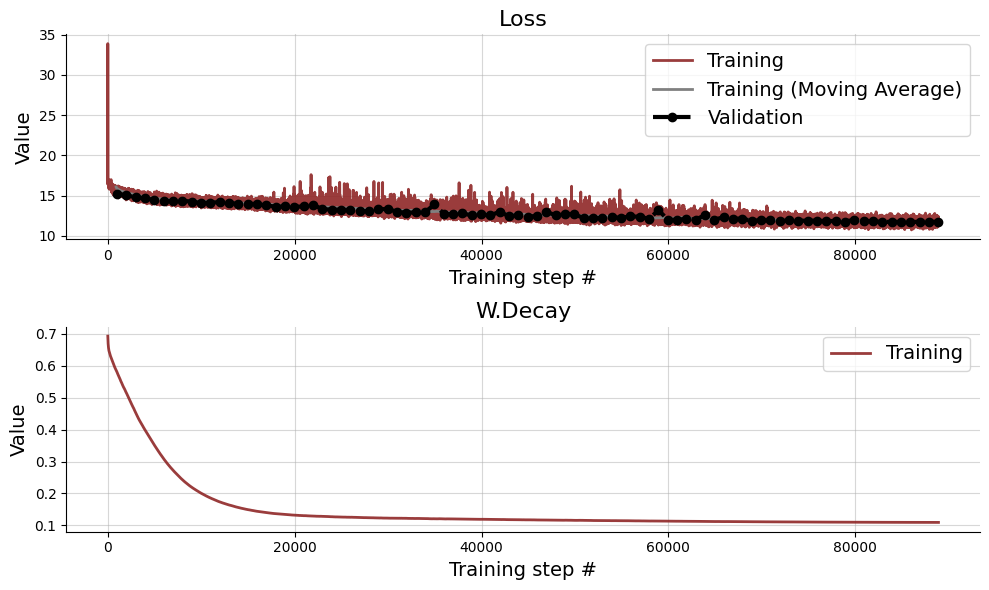

In [146]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], 
                           moving_average=True, fig_size=(10, 6));

In [147]:
test_sims = trainer.configurator(valid_data)

In [148]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples)
prior_draws = renormalize_params(test_sims["parameters"])

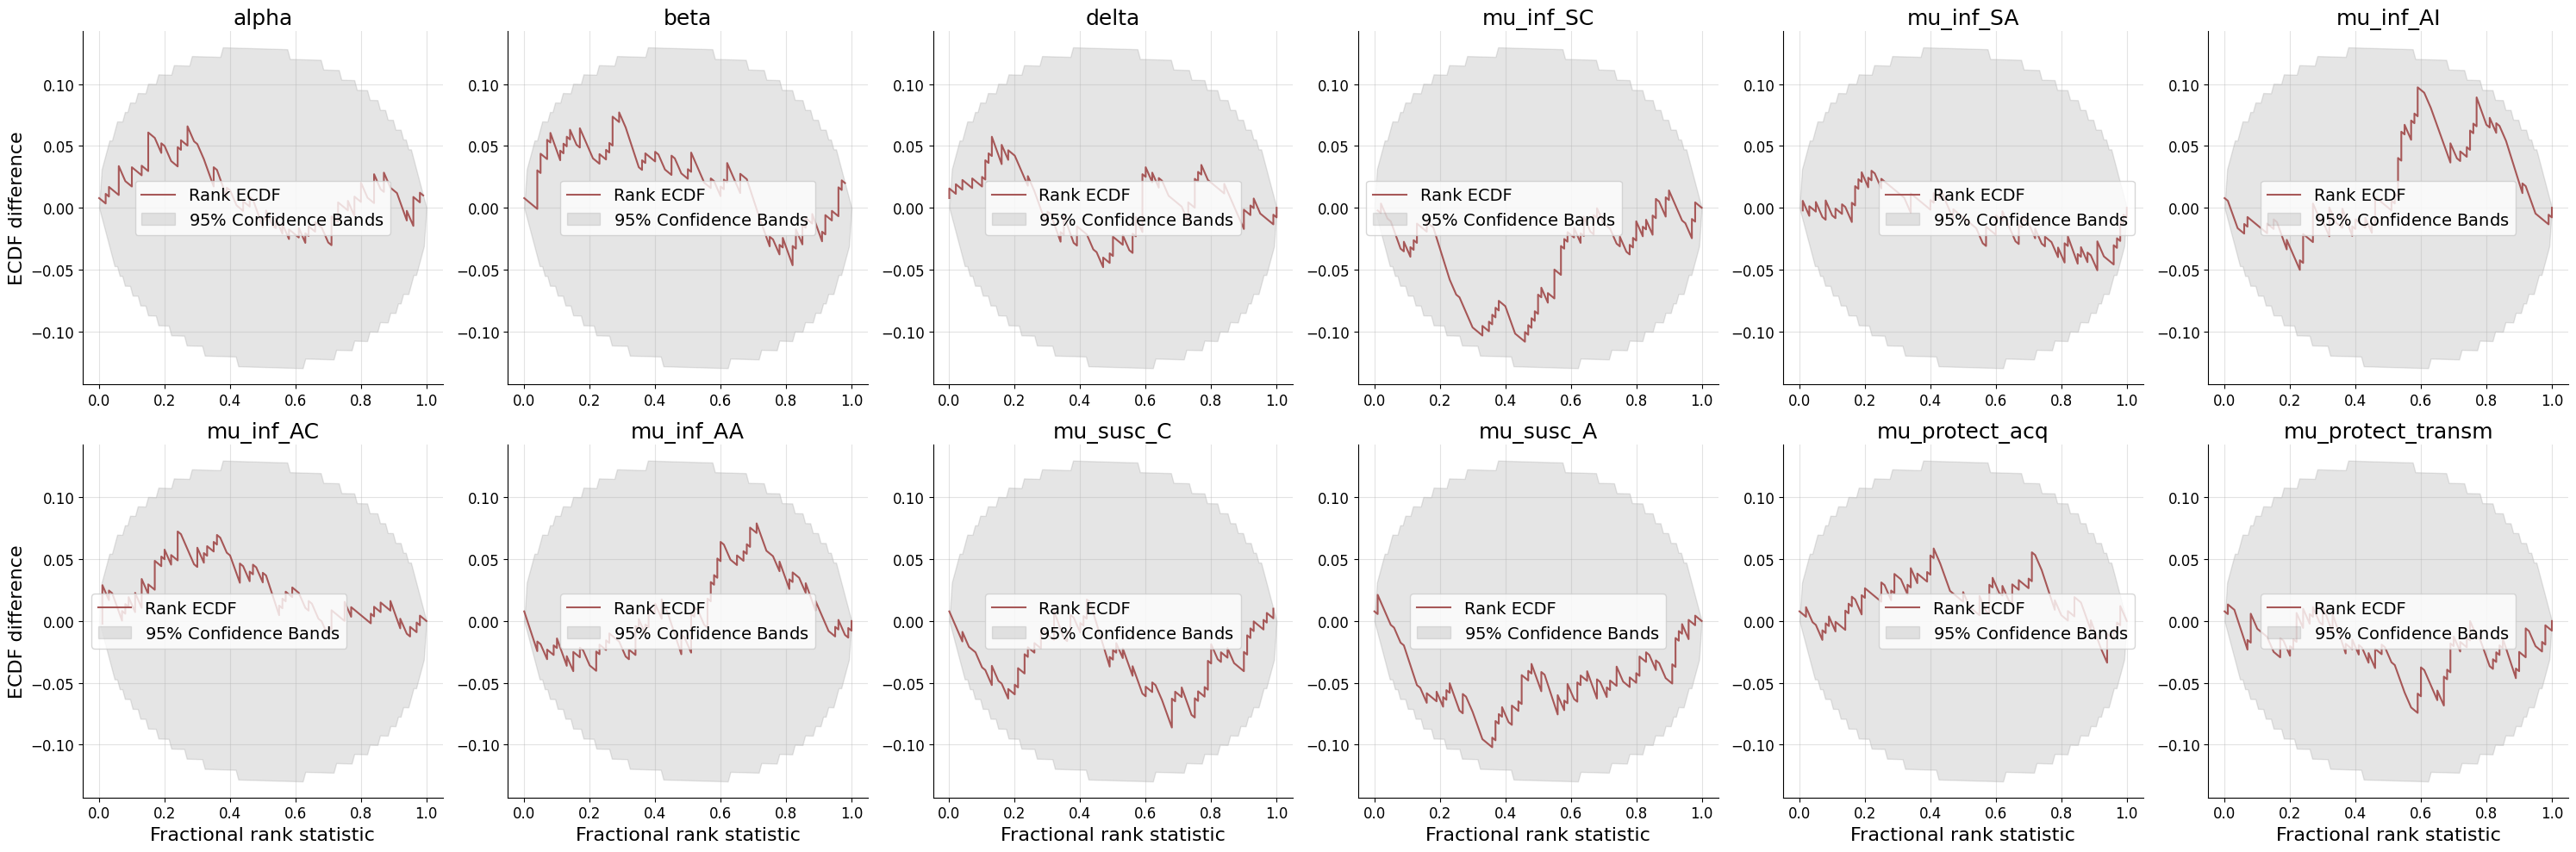

In [149]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names)
fig.savefig('results/'+name+'_sbc.png')

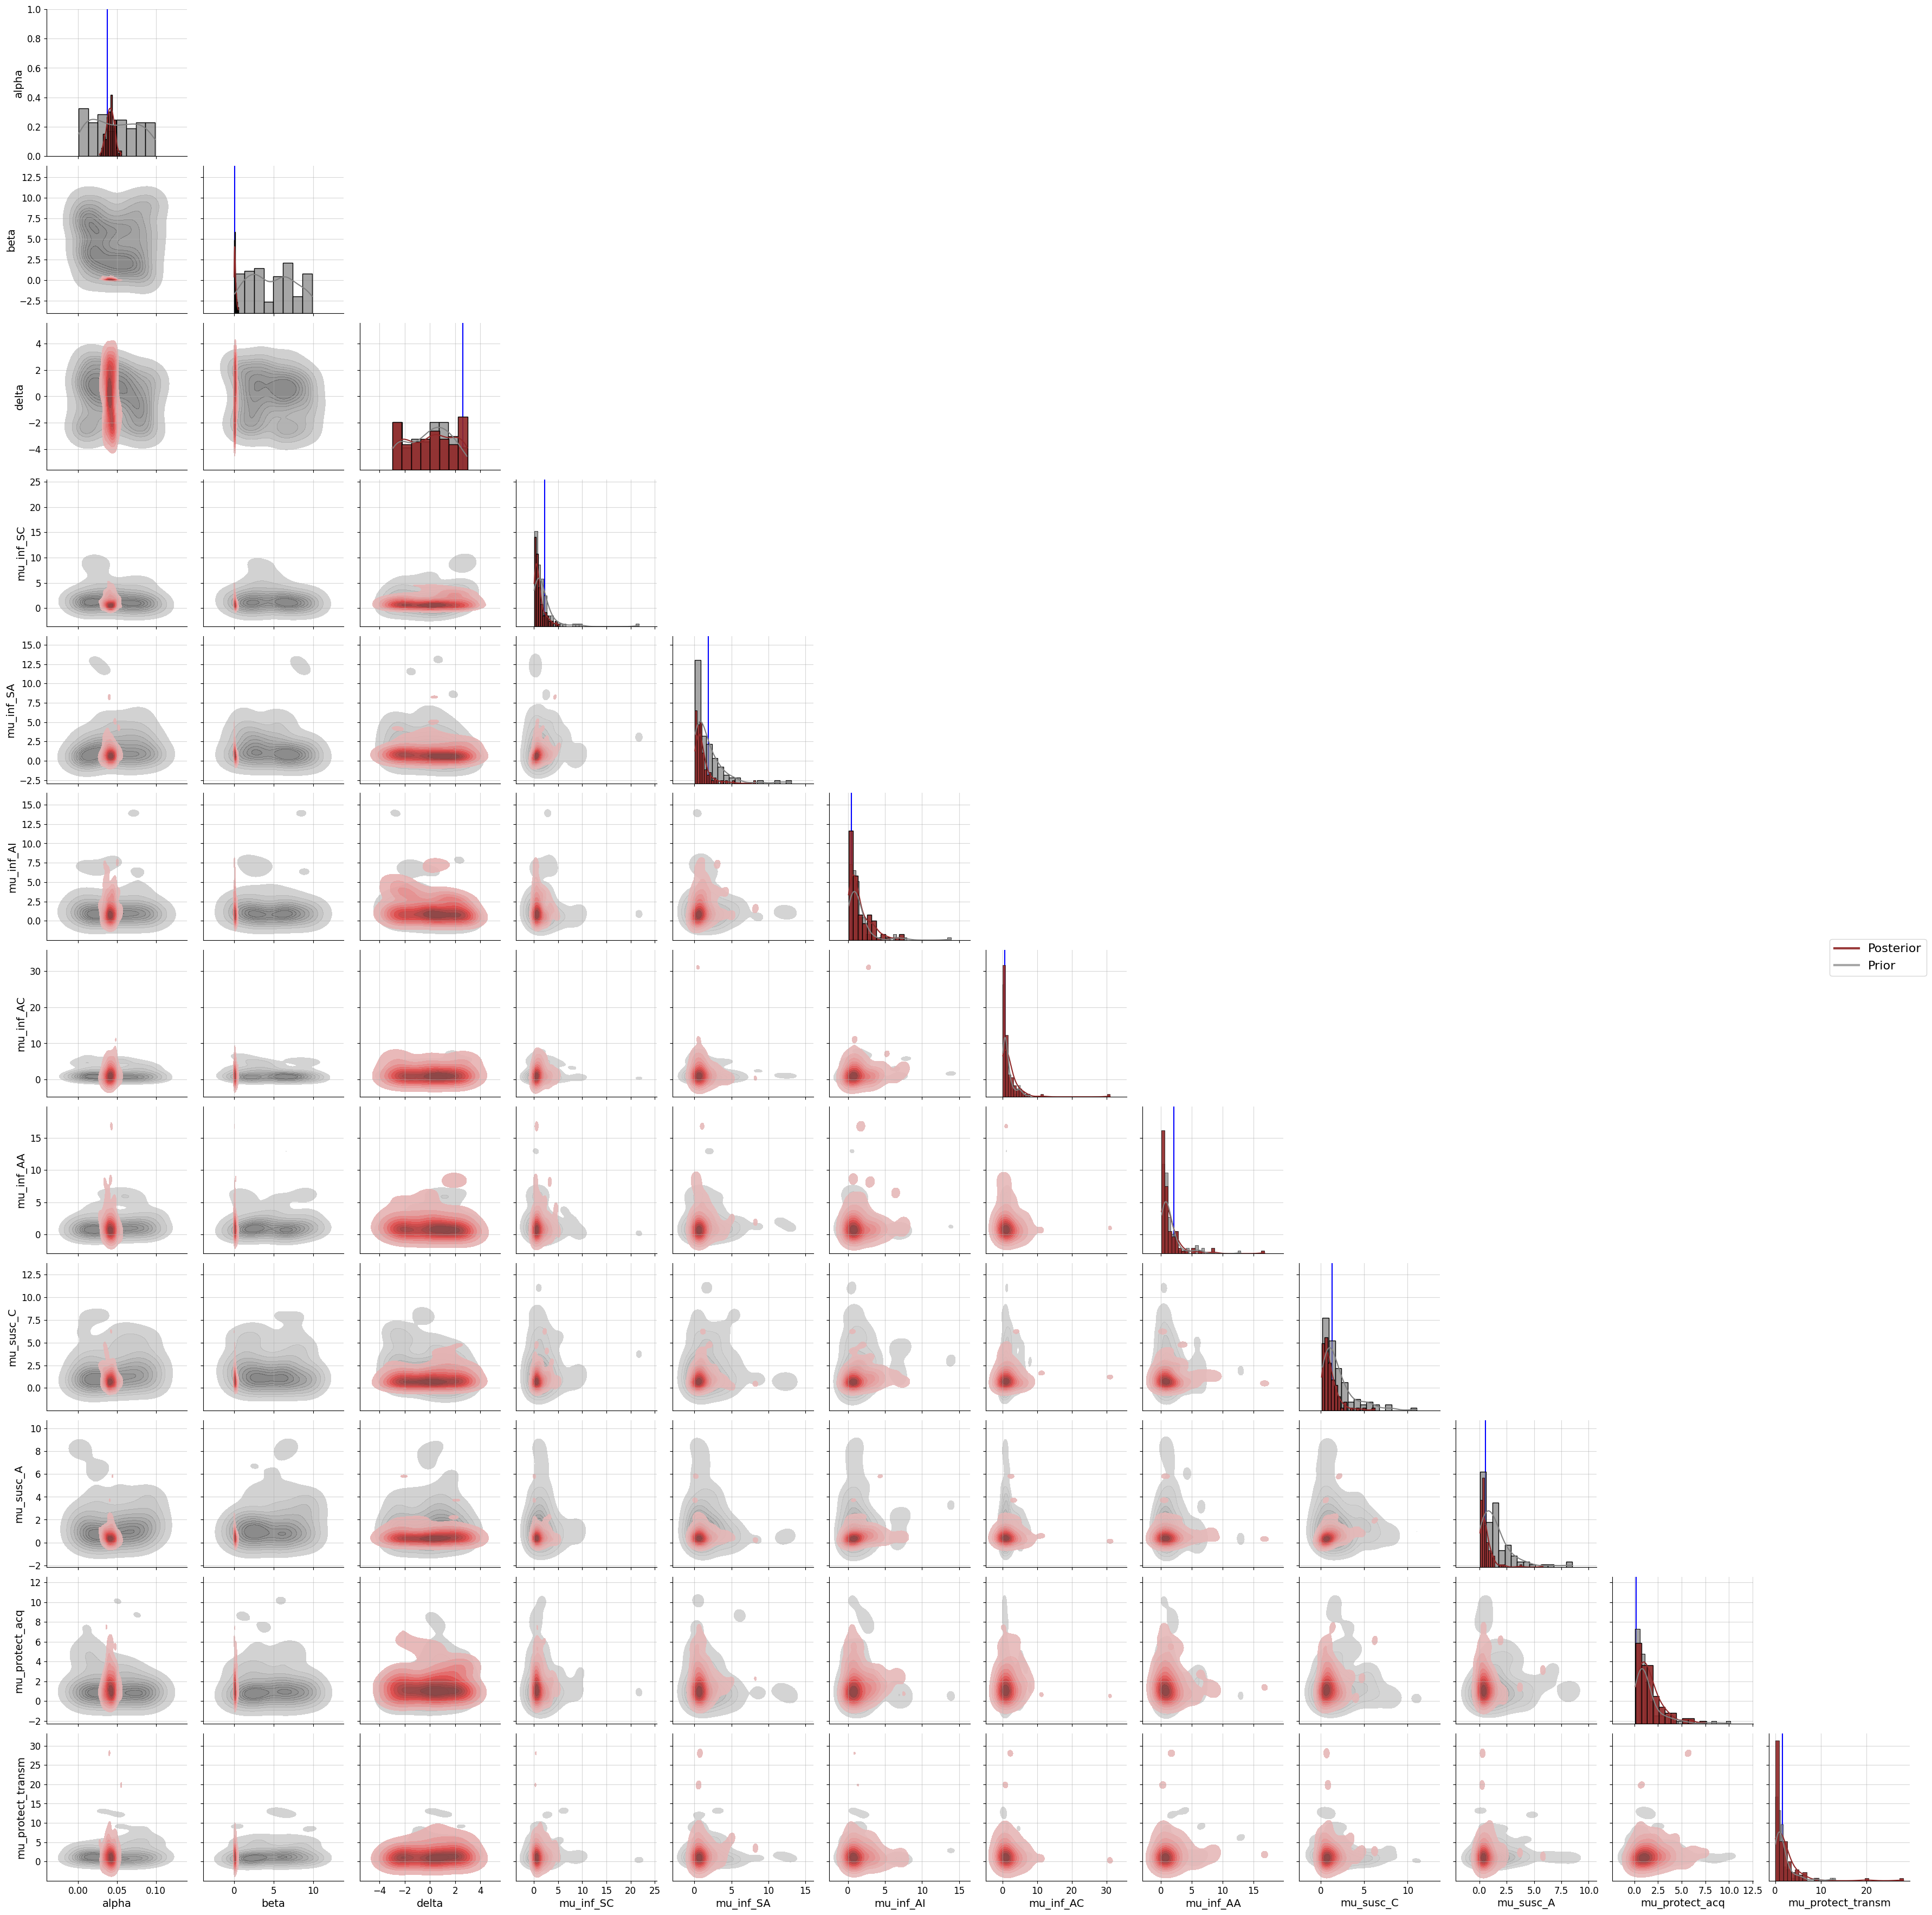

In [150]:
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples)
sample_id = 0
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=posterior_samples[sample_id],
                                       prior_draws=prior_draws[:posterior_samples.shape[1]], param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal the true parameter
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(prior_draws[sample_id][i // len(param_names)], color='b', label='True parameter')

In [151]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

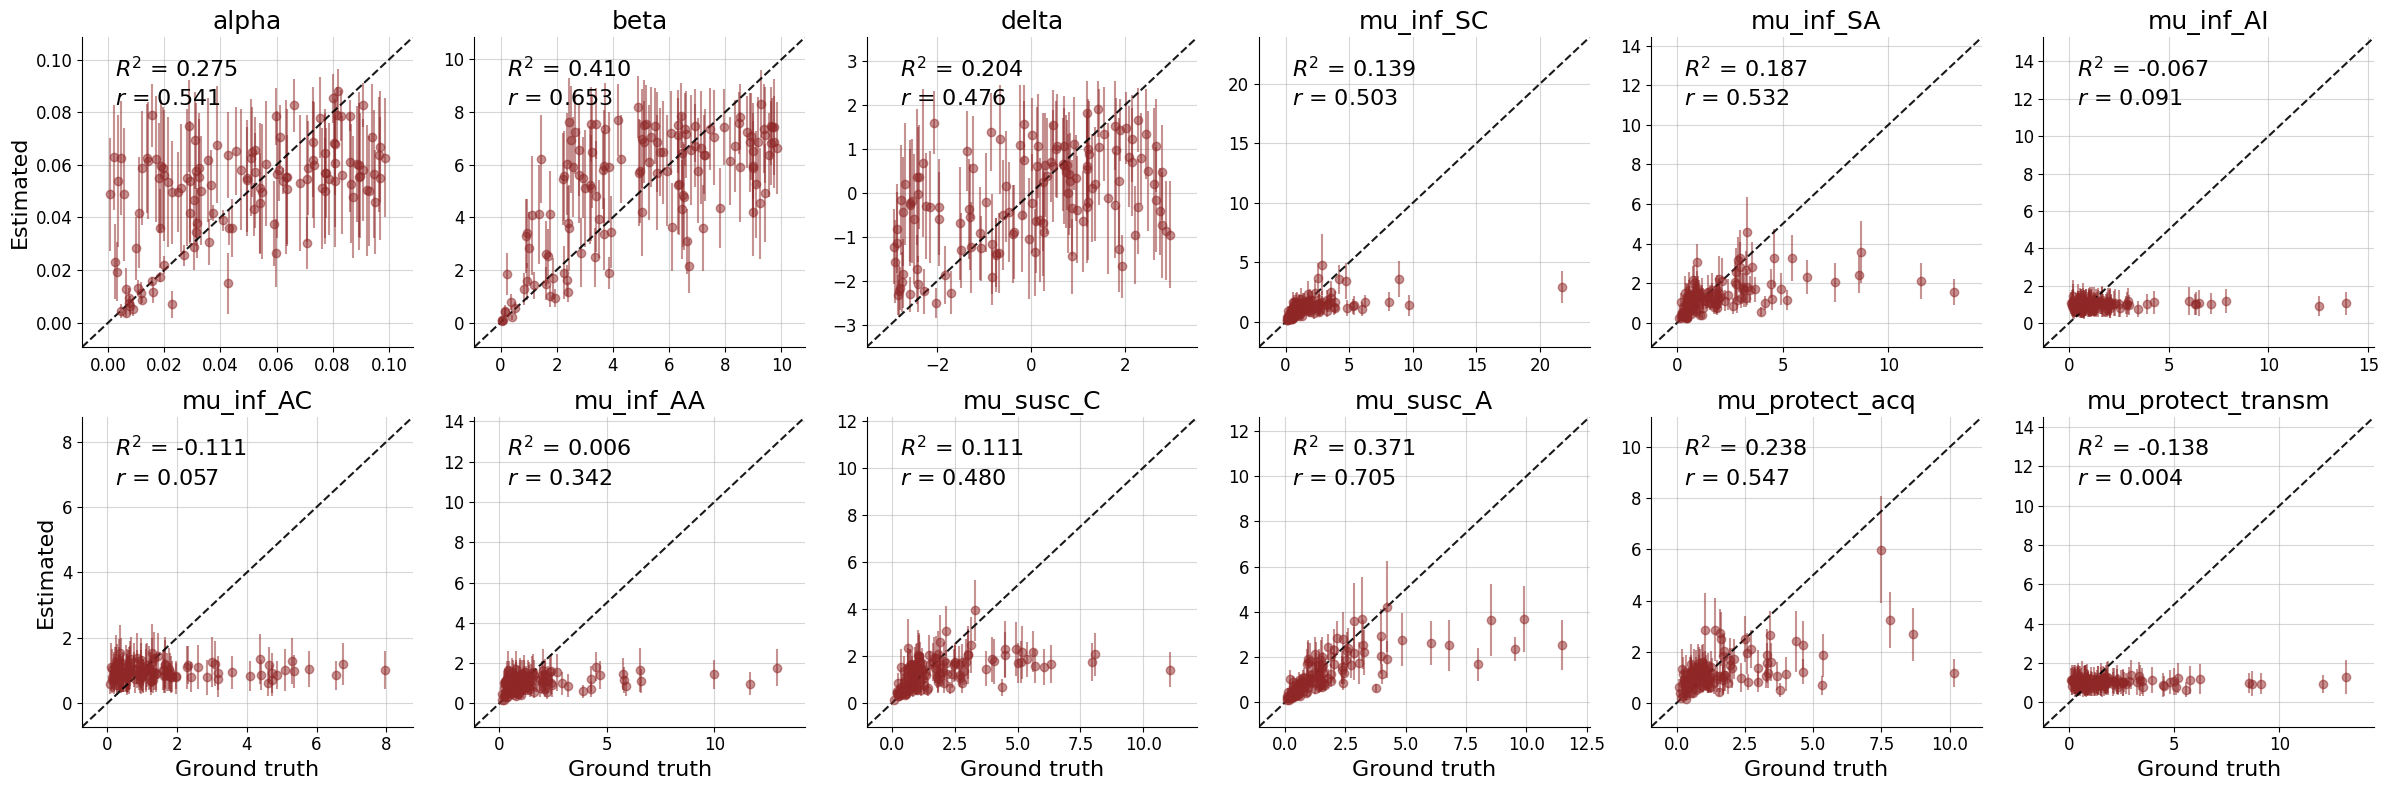

In [152]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=param_names);

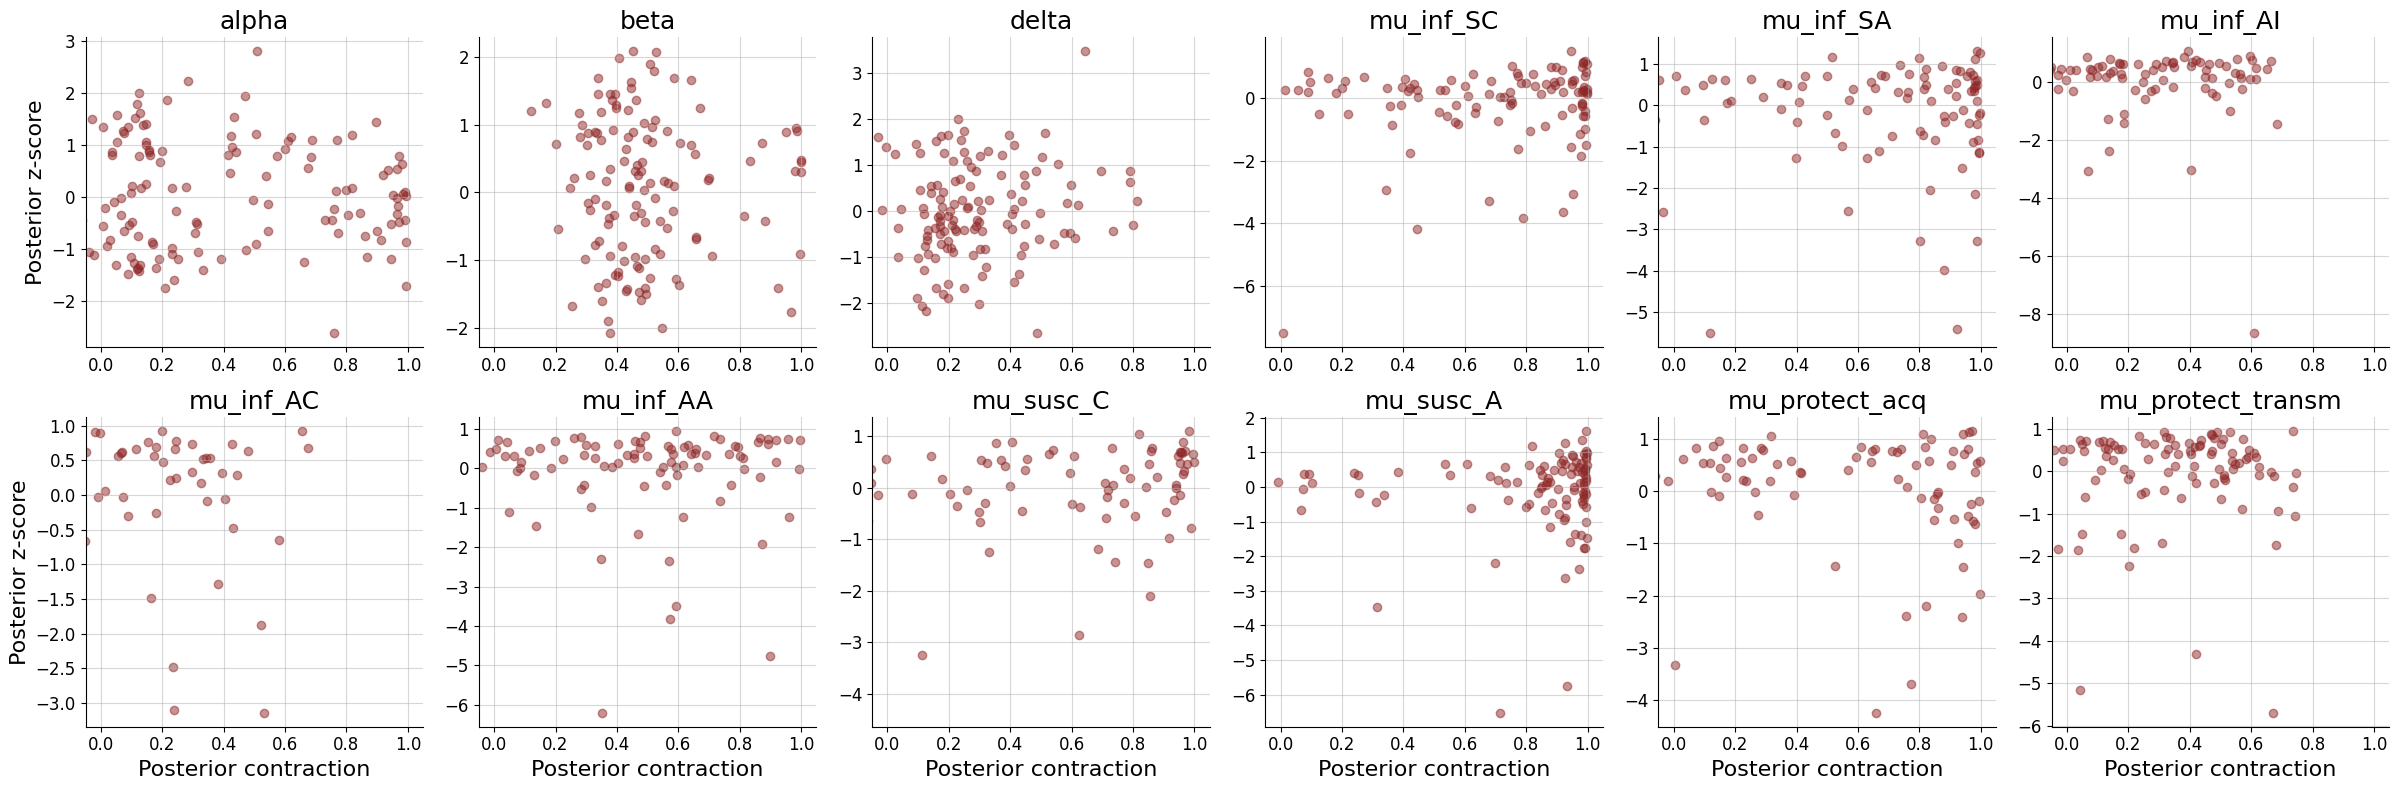

In [153]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

In [154]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])

In [155]:
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', #posterior_samples_reshaped[0, :, :]
                                         metric='euclidean', norm=True, bootstrap=True)

100%|██████████| 100/100 [00:00<00:00, 1739.50it/s]


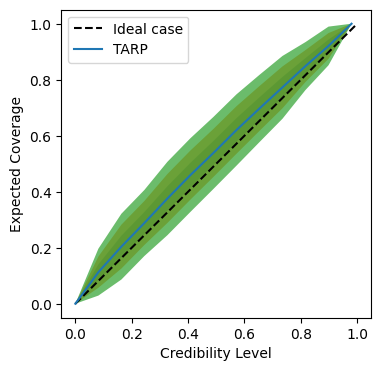

In [156]:
k_sigma = [1, 2, 3]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test on synthetic data

In [157]:
np.random.seed(42)
test_data = generative_model(1)
true_params = test_data['prior_draws'].flatten()
random_sim = bayes_simulator_random(true_params[np.newaxis])
true_params

array([ 0.03745401,  9.50714306,  1.39196365, -1.11188012,  0.31890218,
        0.27904129,  1.01051528, -0.58087813, -0.52516981, -0.57138017,
       -0.92408284, -2.61254901])

In [158]:
# get posterior samples and simulate
if not os.path.exists(checkpoint_path+'/posterior_sim.npy'):
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = renormalize_params(test_posterior_samples)
    
    # simulate the data
    #posterior_sim = bayes_simulator(test_posterior_samples)['sim_data']
    #np.save(checkpoint_path+'/posterior_sim.npy', posterior_sim)
else:
    test_posterior_samples = amortizer.sample(trainer.configurator(test_data), n_samples=100)
    test_posterior_samples = renormalize_params(test_posterior_samples)
    
    posterior_sim = np.load(checkpoint_path+'/posterior_sim.npy')

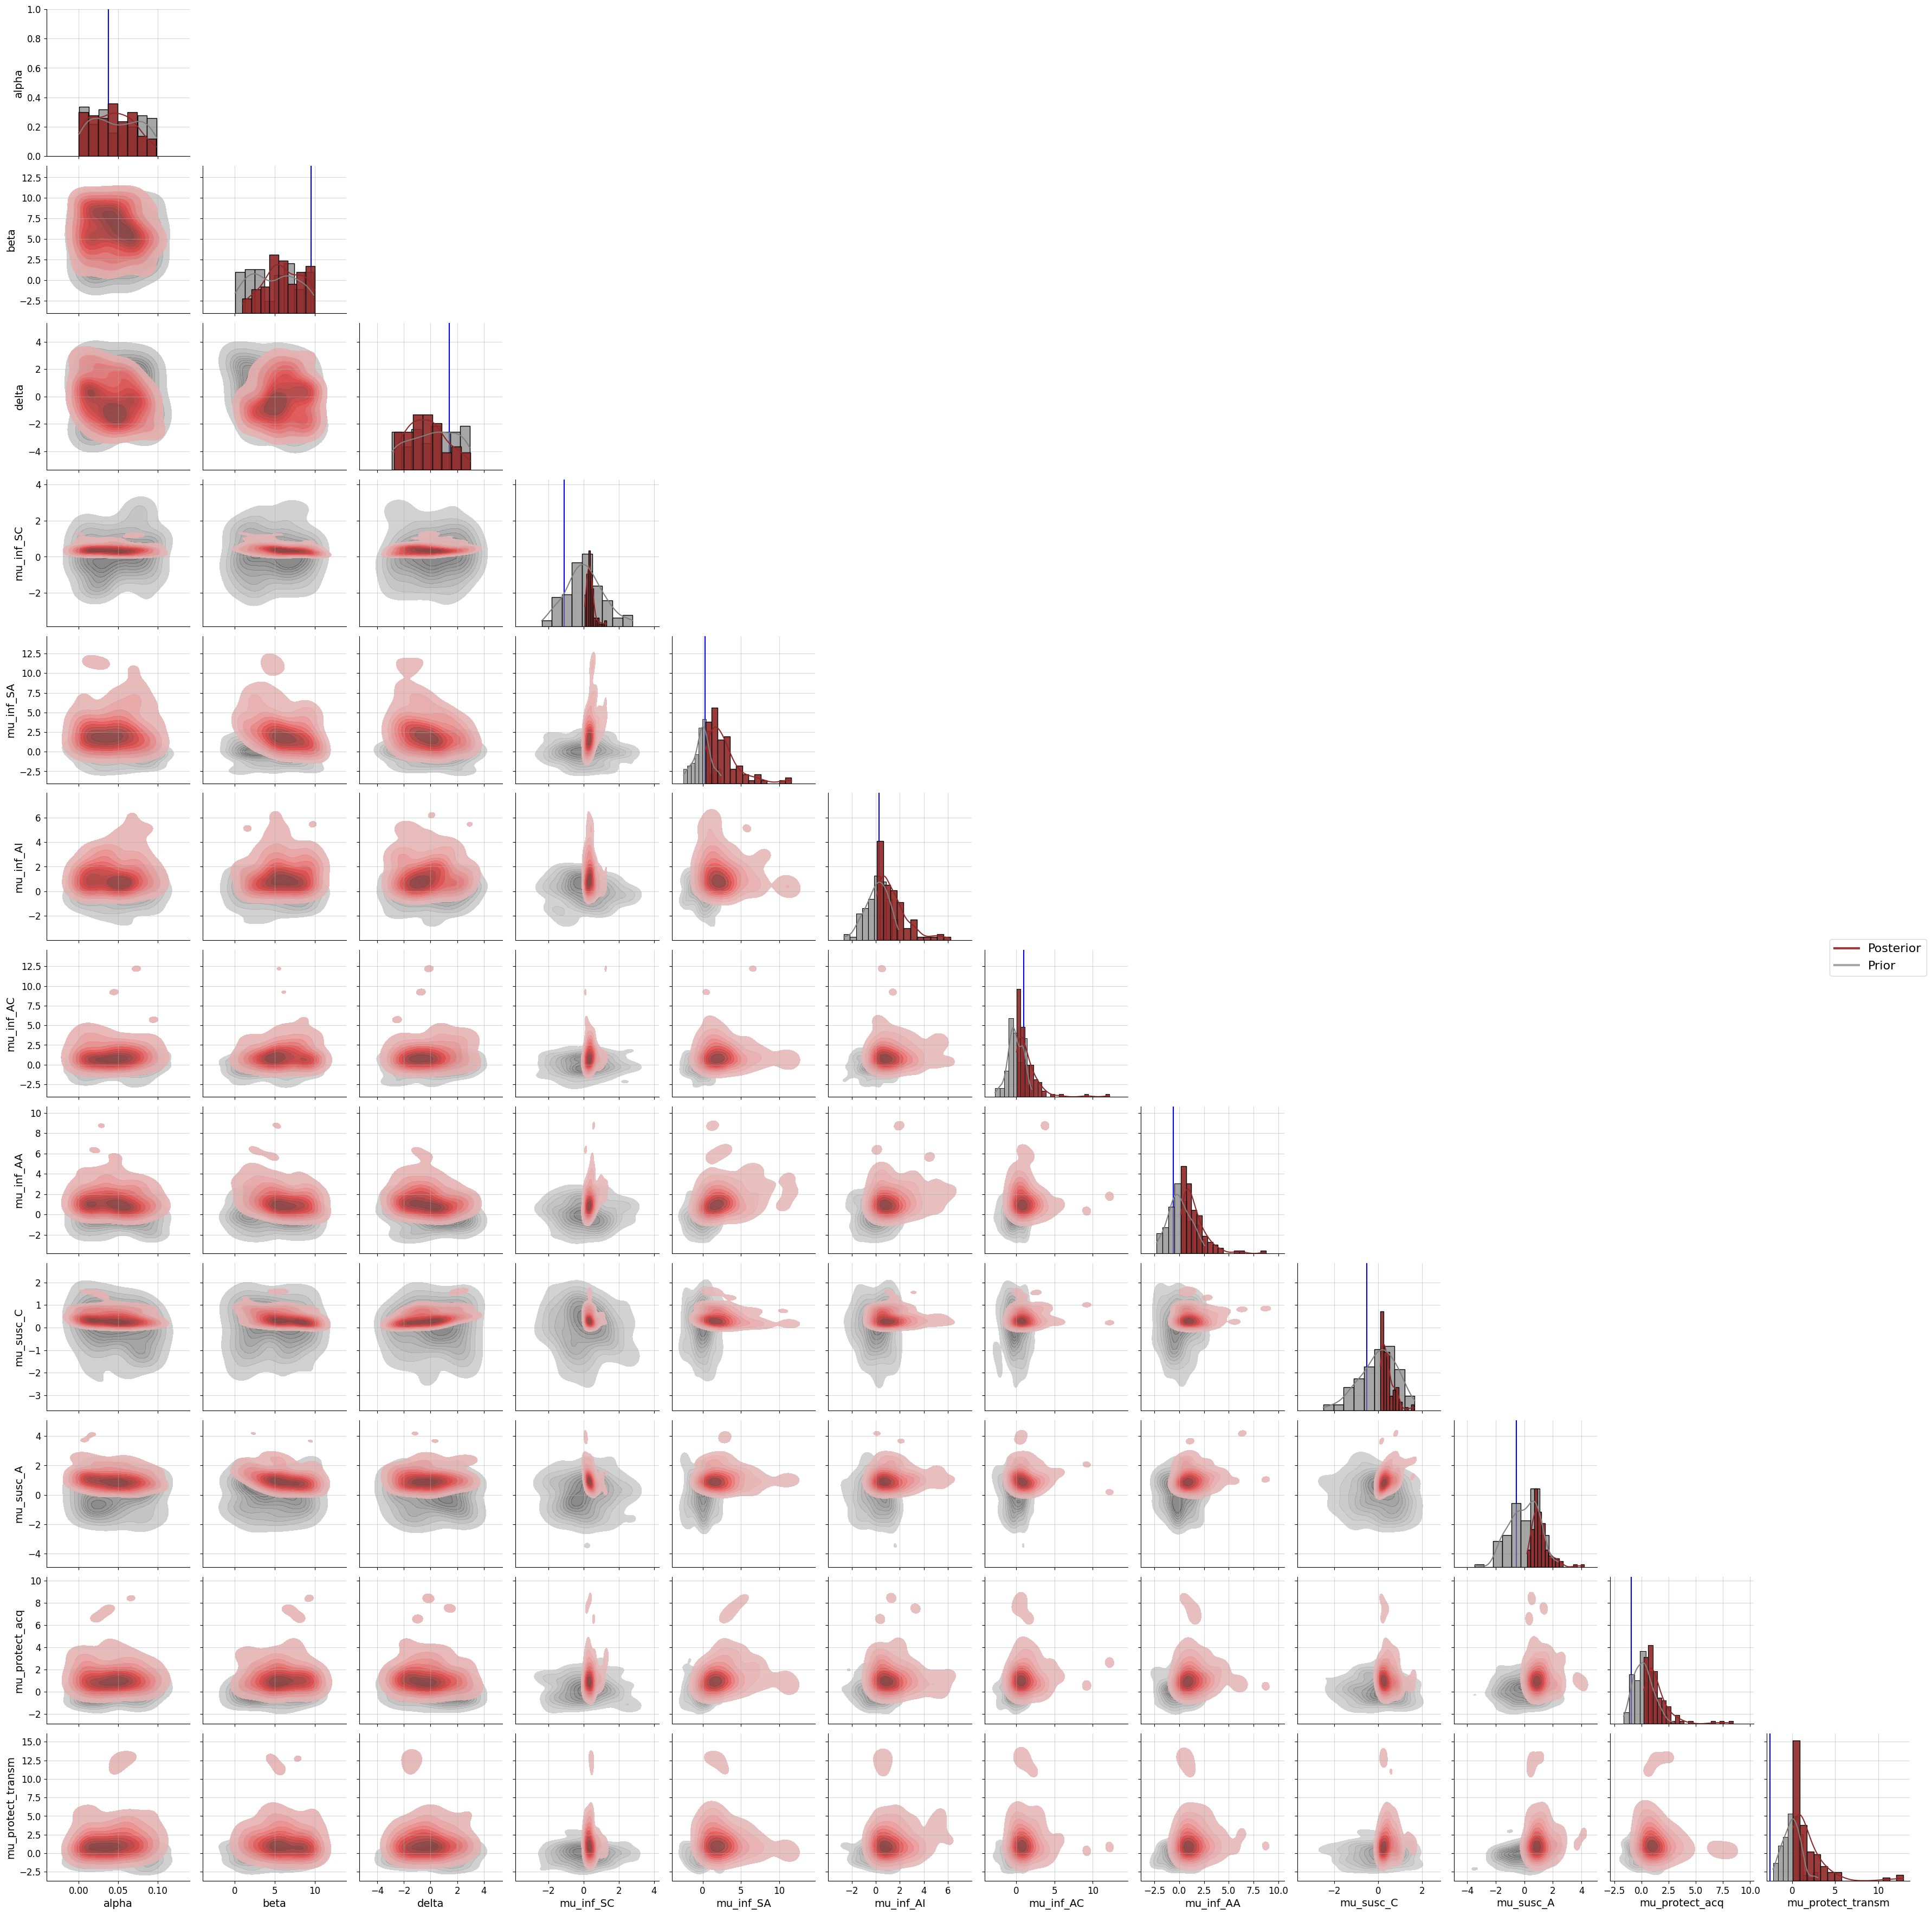

In [159]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=test_posterior_samples,
                                       prior=prior, 
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [160]:
rand_posterior_samples = amortizer.sample(trainer.configurator(random_sim), n_samples=100)
rand_posterior_samples = renormalize_params(rand_posterior_samples)

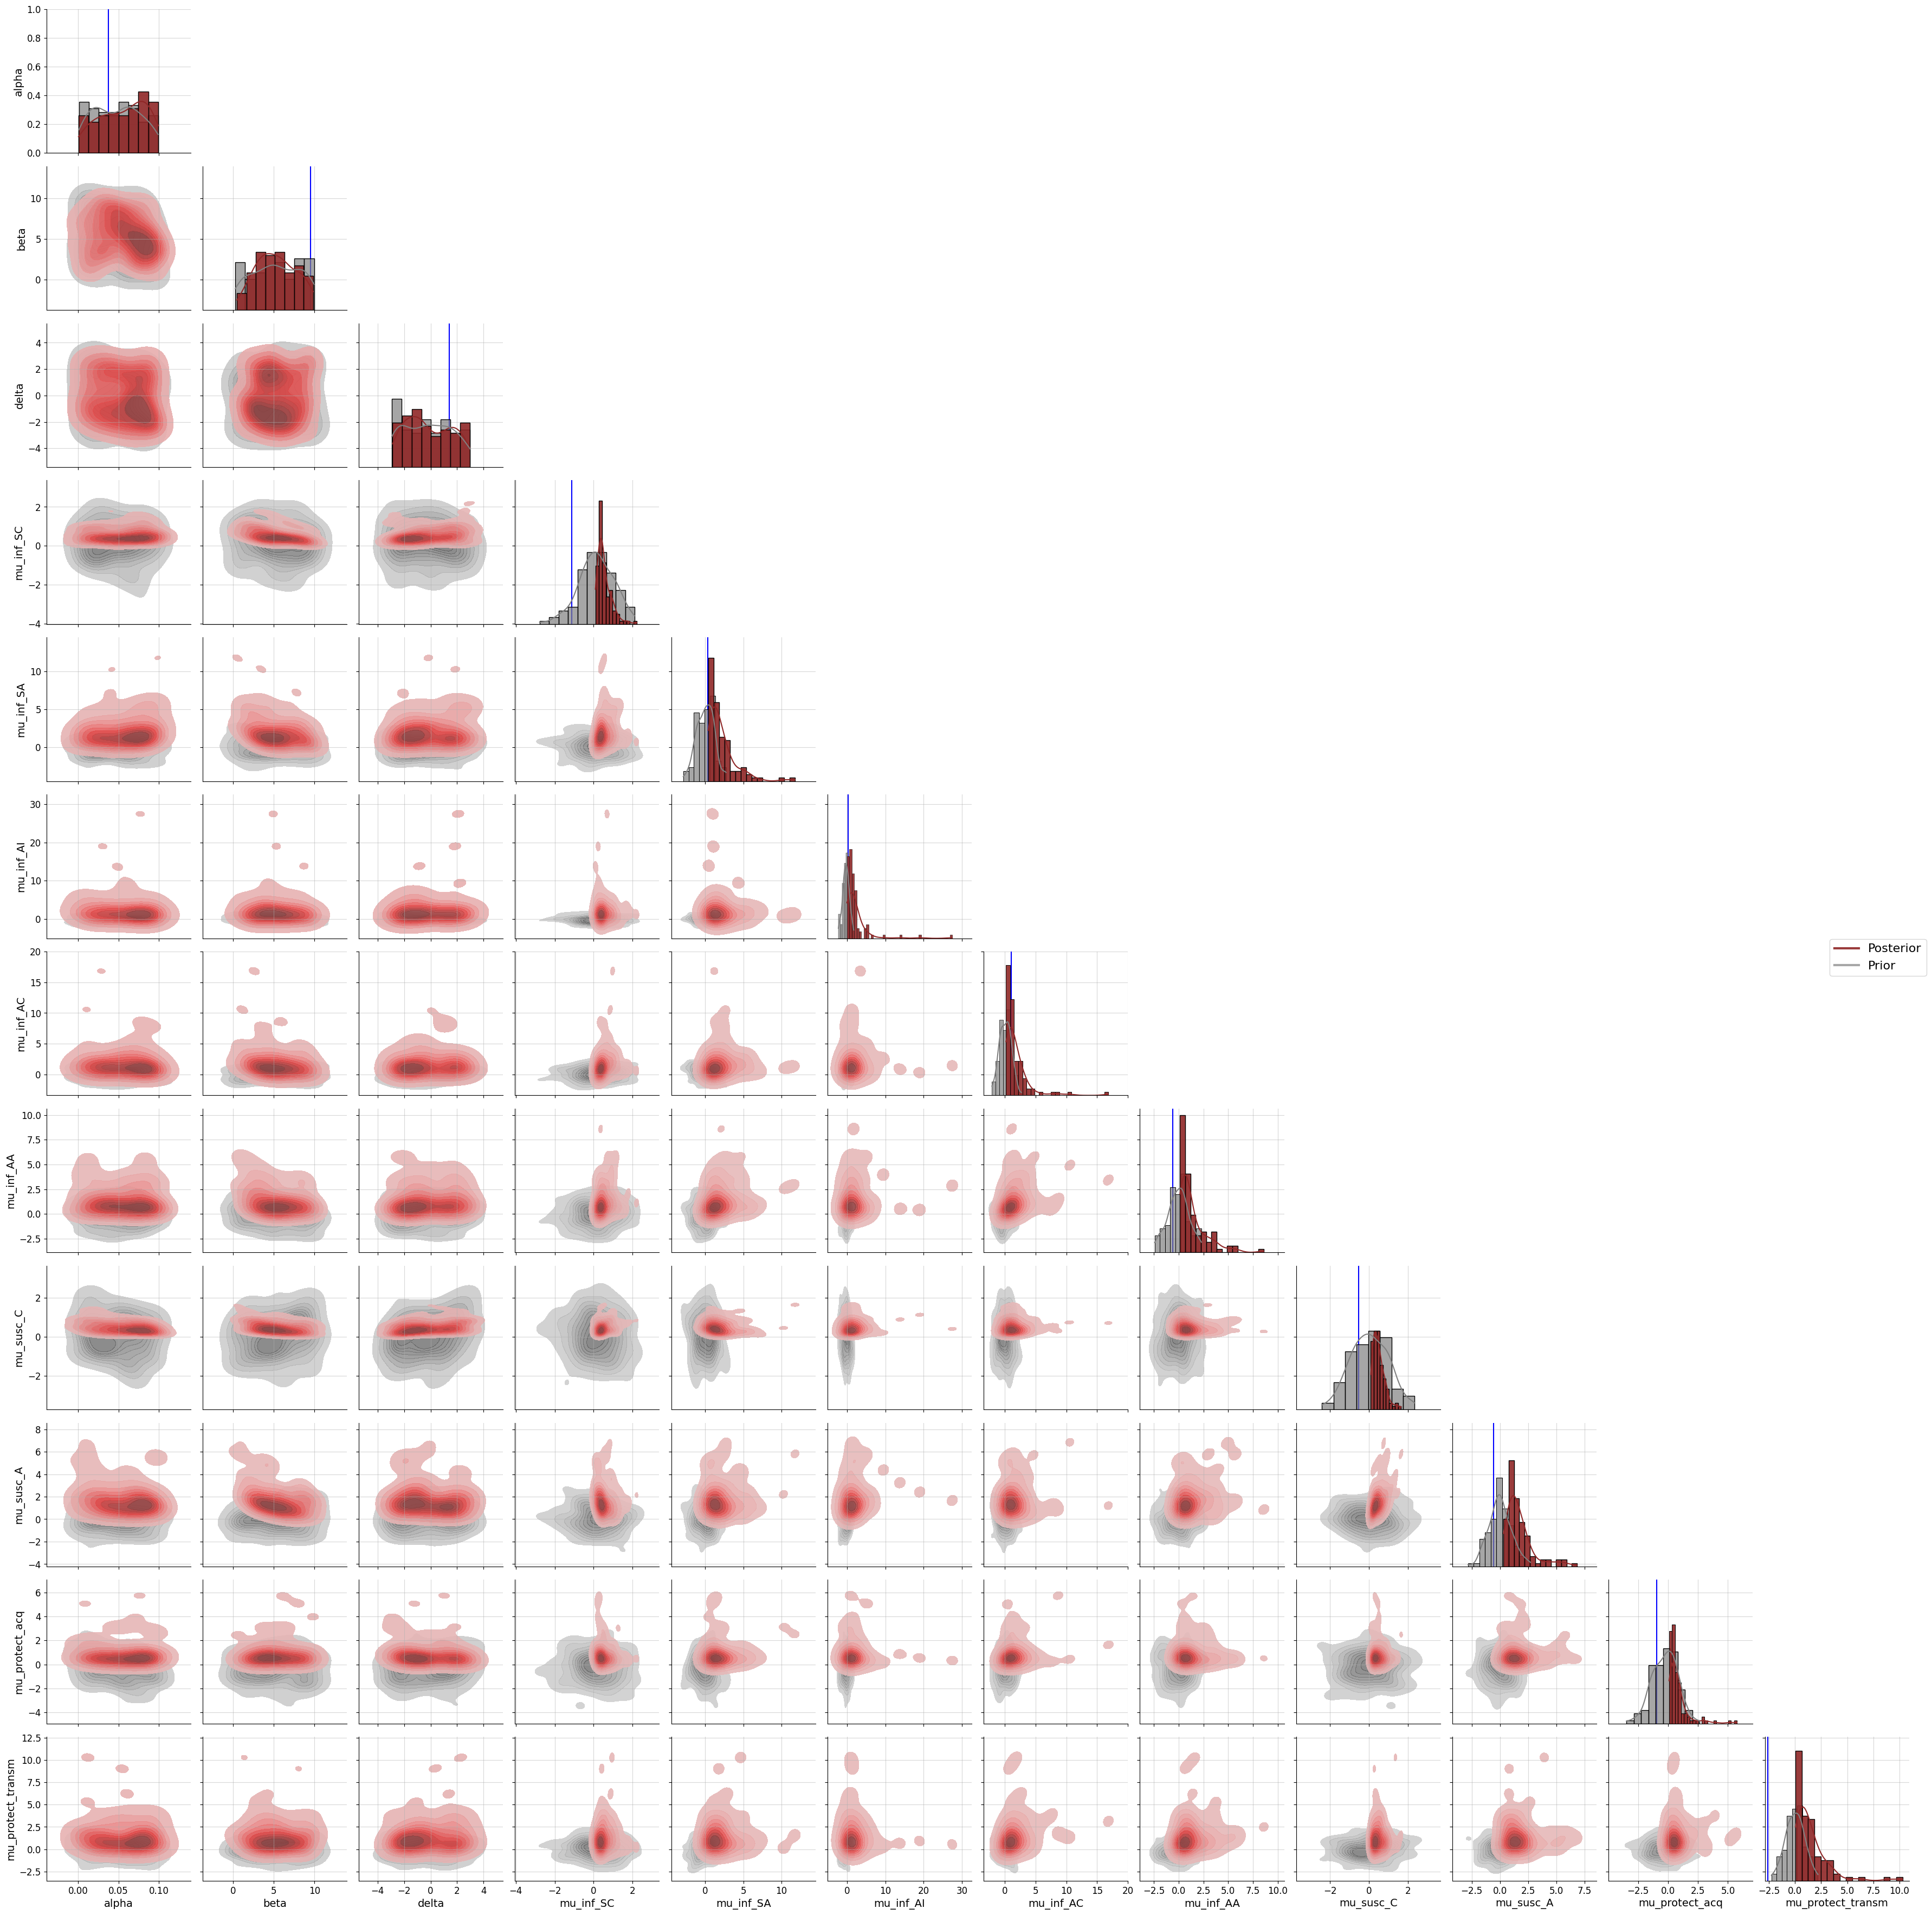

In [161]:
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=rand_posterior_samples,
                                       prior=prior, 
                                       param_names=param_names)
# from figure get axis
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names) + 1):
        a.axvline(true_params[i // len(param_names)], color='b', label='True parameter')

In [162]:
test_sims = trainer.configurator(valid_data)
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples)
prior_draws = renormalize_params(test_sims["parameters"])

test_sims_rand = trainer.configurator(valid_data_rand)
posterior_samples_rand = amortizer.sample(test_sims_rand, n_samples=100)
posterior_samples_rand = renormalize_params(posterior_samples_rand)
prior_draws_rand = renormalize_params(test_sims_rand["parameters"])

assert (prior_draws_rand-prior_draws).sum() == 0, 'Prior draws are not the same'

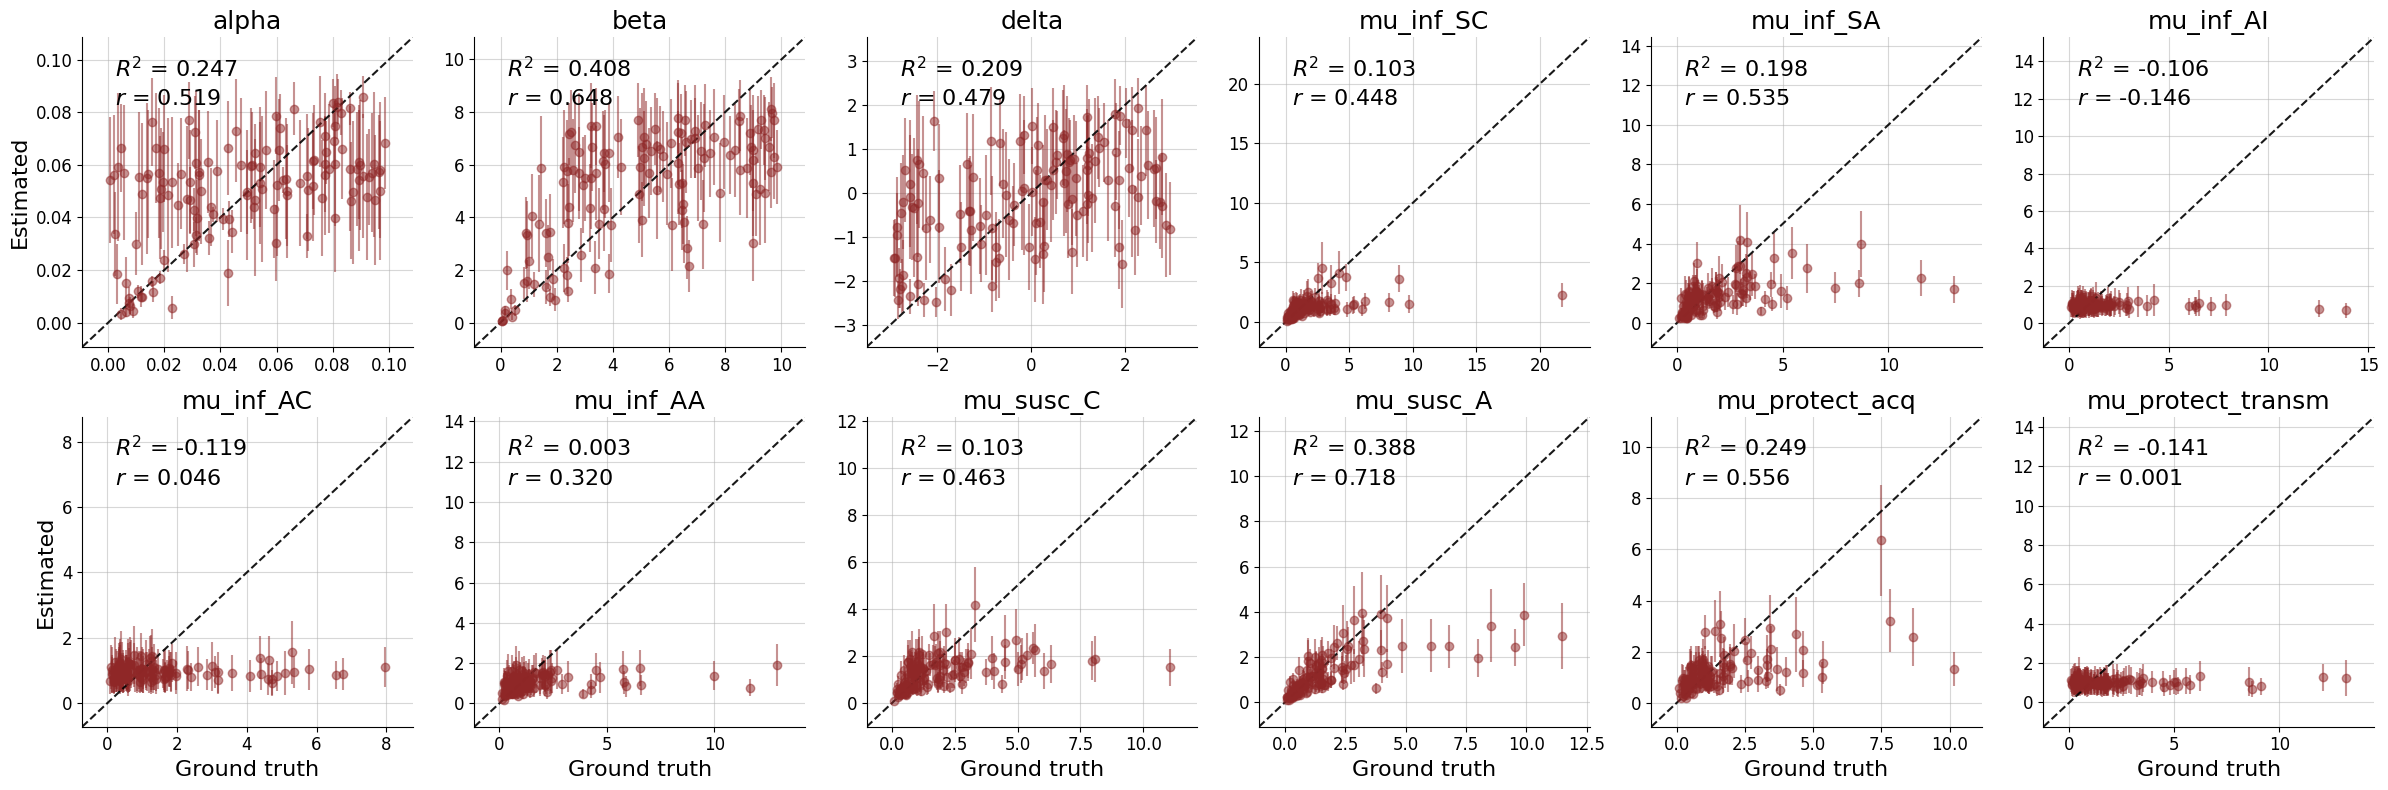

In [163]:
fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names)
fig.savefig('results/'+name+'_recovery_pedcov.png')

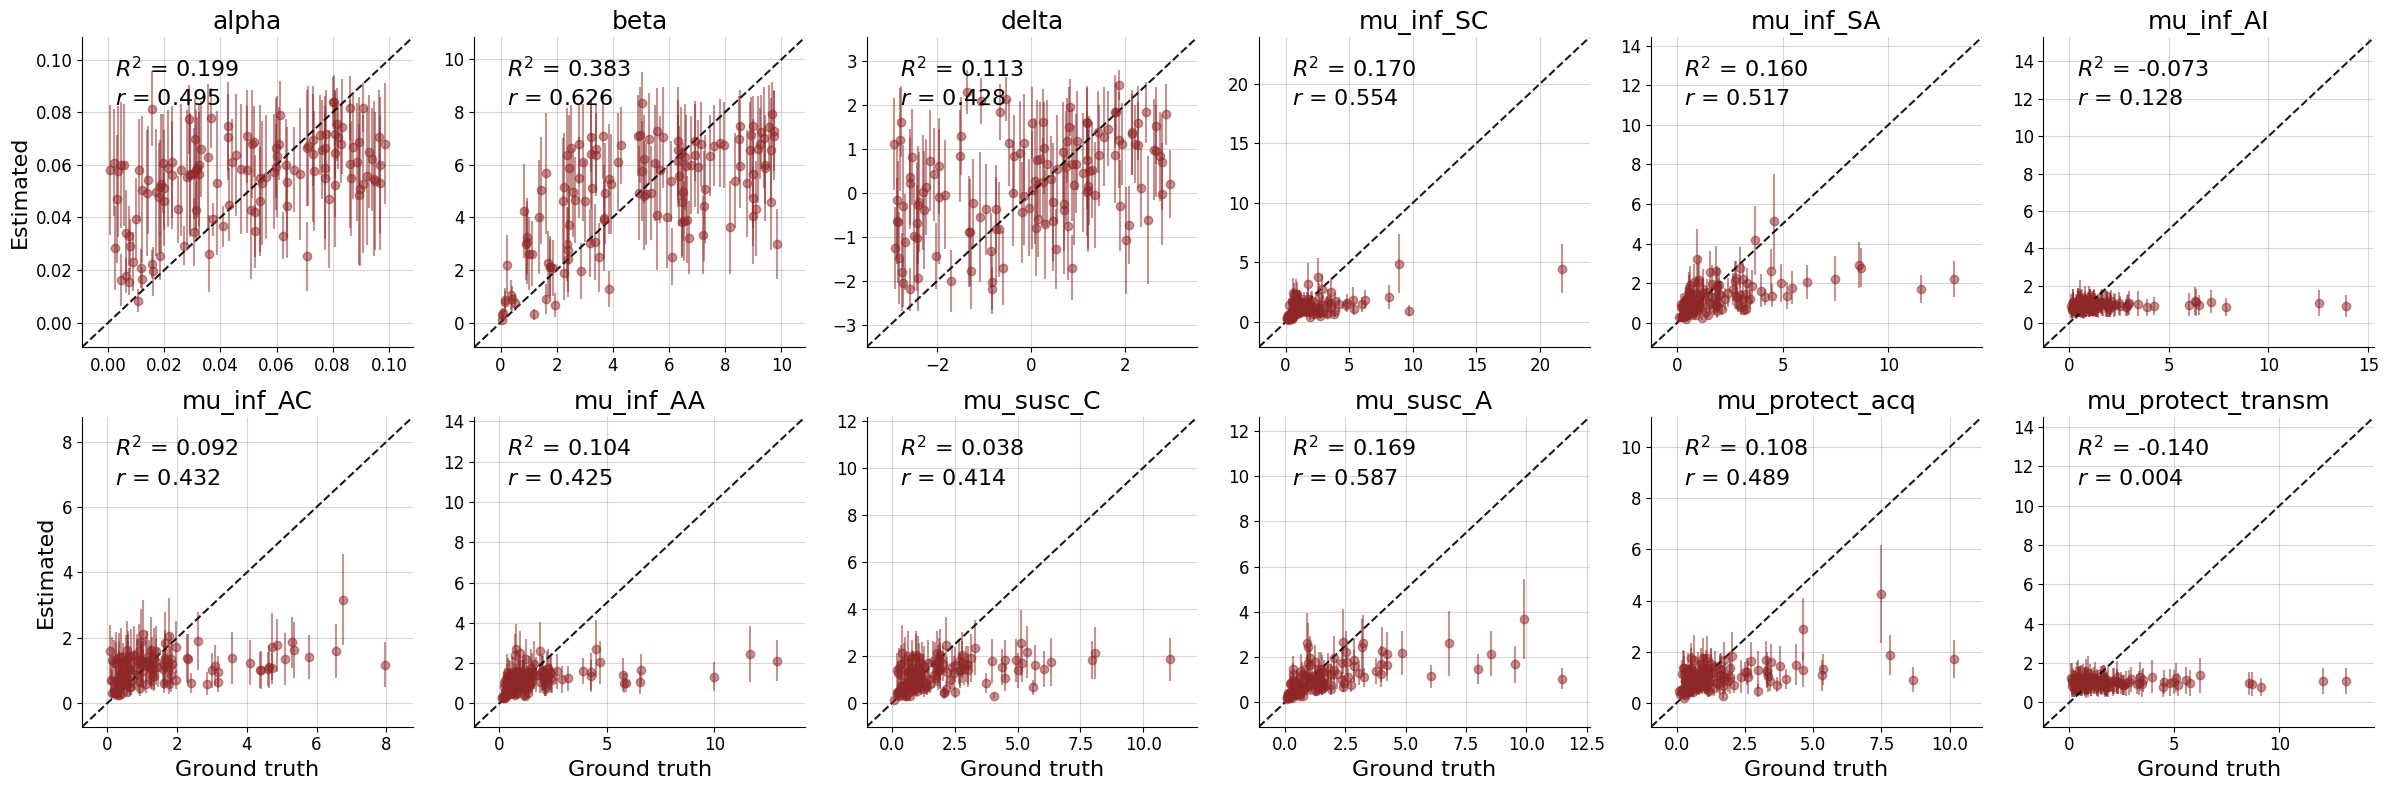

In [140]:
fig = bf.diagnostics.plot_recovery(posterior_samples_rand, prior_draws_rand, param_names=param_names)
fig.savefig('results/'+name+'_recovery_rand.png')